In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import plotly.express as px
import seaborn as sns

from sklearn import manifold
# from sklearn.manifold import TSNE
from sklearn import decomposition
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans 
#from sklearn.cluster import DBSCAN

from imblearn.over_sampling import RandomOverSampler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif  
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, KBinsDiscretizer, OrdinalEncoder, StandardScaler, PowerTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from yellowbrick.classifier.rocauc import roc_auc 

SEED = 123
np.random.seed(SEED)

import warnings
warnings.filterwarnings('ignore')   # remove warnings

In [2]:
path = '../tbs_housing_data/wine-quality-white-and-red.csv'

In [3]:
data = pd.read_csv(path)
data

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [4]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6497 non-null   float64
 2   volatile acidity      6497 non-null   float64
 3   citric acid           6497 non-null   float64
 4   residual sugar        6497 non-null   float64
 5   chlorides             6497 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6497 non-null   float64
 10  sulphates             6497 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [6]:
data.quality.value_counts()

quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64

In [7]:
data.quality = data.quality.apply(lambda x: 4 if x == 3 else x)
data.quality = data.quality.apply(lambda x: 8 if x == 9 else x)
data.quality.value_counts()

quality
6    2836
5    2138
7    1079
4     246
8     198
Name: count, dtype: int64

In [8]:
data.columns

Index(['type', 'fixed acidity', 'volatile acidity', 'citric acid',
       'residual sugar', 'chlorides', 'free sulfur dioxide',
       'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol',
       'quality'],
      dtype='object')

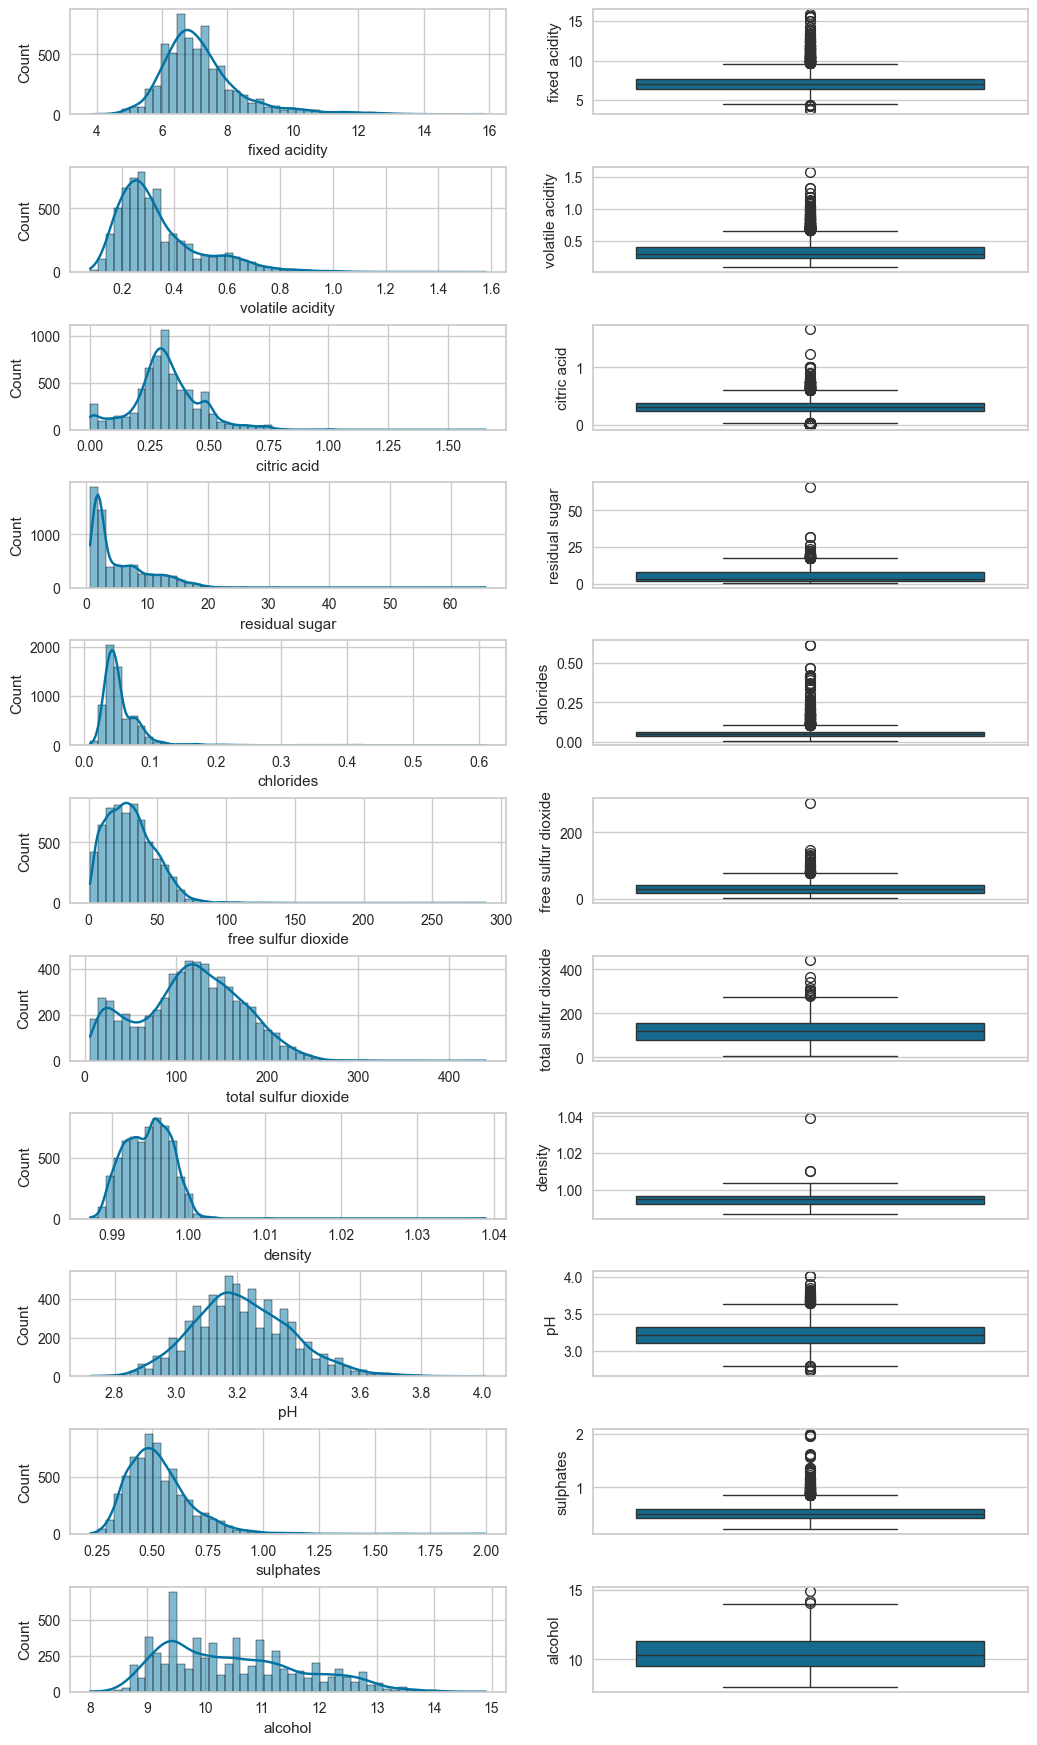

In [9]:
fig, axs = plt.subplots(11, 2)
fig.tight_layout(pad=0.2)  
fig.set_size_inches(10, 18, forward=True)  

for i in range(11):
    rows=i
    sns.histplot(data=data, x=['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide',
                               'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol'][i], kde=True, ax=axs[rows, 0], bins=50)
    sns.boxplot(data=data, y=['fixed acidity', 'volatile acidity', 'citric acid','residual sugar', 'chlorides', 'free sulfur dioxide',
                              'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol'][i], ax=axs[rows, 1])
    plt.subplots_adjust(hspace=0.5, wspace=0.2)
plt.show()

<Axes: xlabel='type', ylabel='Count'>

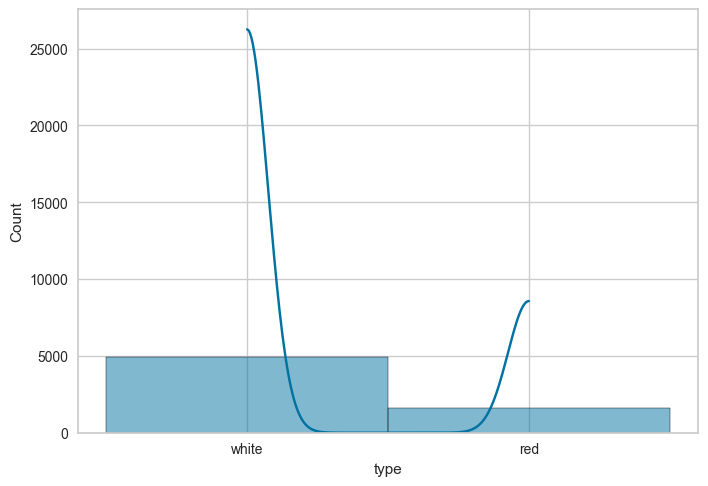

In [10]:
sns.histplot(data=data, x='type', kde=True, bins=2)

<Axes: xlabel='quality', ylabel='Count'>

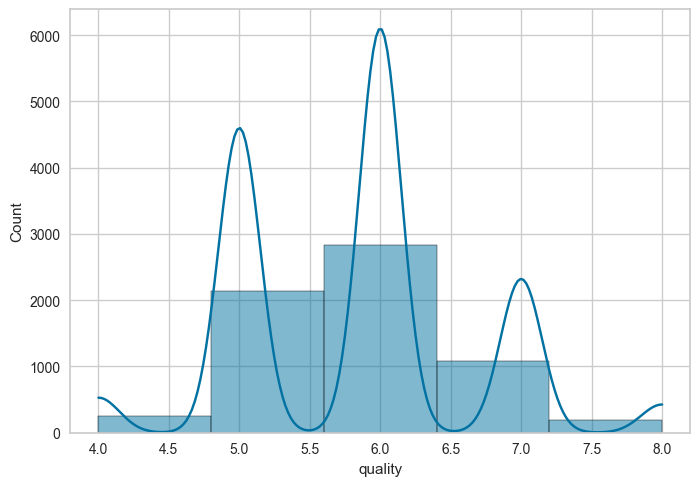

In [11]:
sns.histplot(data=data, x='quality', kde=True, bins=5)

# Make features

In [12]:
data['type'] = data['type'].apply(lambda x: 1 if x == 'red' else 0)

In [13]:
X = data.drop('quality', axis=1)
y = data['quality']

## K-means/ordinations

In [14]:
X_to_unsup = X[['type', 'residual sugar', 'alcohol', 'pH']]
X_to_unsup

,type,residual sugar,alcohol,pH
0,0,20.7,8.8,3.00
1,0,1.6,9.5,3.30
2,0,6.9,10.1,3.26
3,0,8.5,9.9,3.19
4,0,8.5,9.9,3.19
...,...,...,...,...
6492,1,2.0,10.5,3.45
6493,1,2.2,11.2,3.52
6494,1,2.3,11.0,3.42
6495,1,2.0,10.2,3.57


In [15]:
scaler = StandardScaler()
X_to_unsup_scaled = scaler.fit_transform(X_to_unsup)

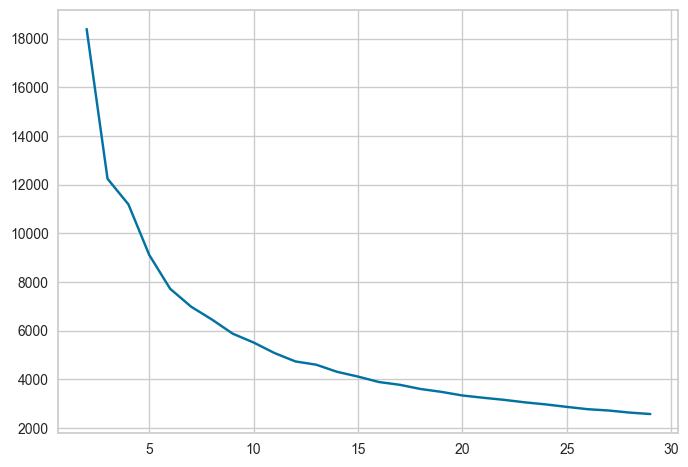

In [16]:
distortion = []
K = range(2, 30)
for k in K:
    model = KMeans(n_clusters=k, random_state=SEED)
    model.fit(X_to_unsup_scaled)
    distortion.append(model.inertia_)         
       
x_axis=[i for i in range(2,30)]
y_axis=distortion
plt.plot(x_axis, y_axis)

In [17]:
model_km = KMeans(n_clusters=5, random_state=SEED)
model_km.fit(X_to_unsup_scaled)
km_labels_vessels = model_km.labels_

In [18]:
np.unique_counts(km_labels_vessels)

UniqueCountsResult(values=array([0, 1, 2, 3, 4], dtype=int32), counts=array([1544, 1770,  930,  669, 1584]))

In [19]:
mds = manifold.MDS(n_components=2, max_iter=50, dissimilarity="euclidean", n_jobs=15)
mds_proc = mds.fit(X_to_unsup_scaled).embedding_
print(mds_proc.shape)
ordination_mds = pd.DataFrame(mds_proc, columns=['X', 'Y'])  
    
       
pca = decomposition.PCA(n_components=2)
pca_proc = pca.fit_transform(X_to_unsup_scaled)
print(pca_proc.shape)
ordination_pca = pd.DataFrame(pca_proc, columns=['X', 'Y']) 

(6497, 2)
(6497, 2)


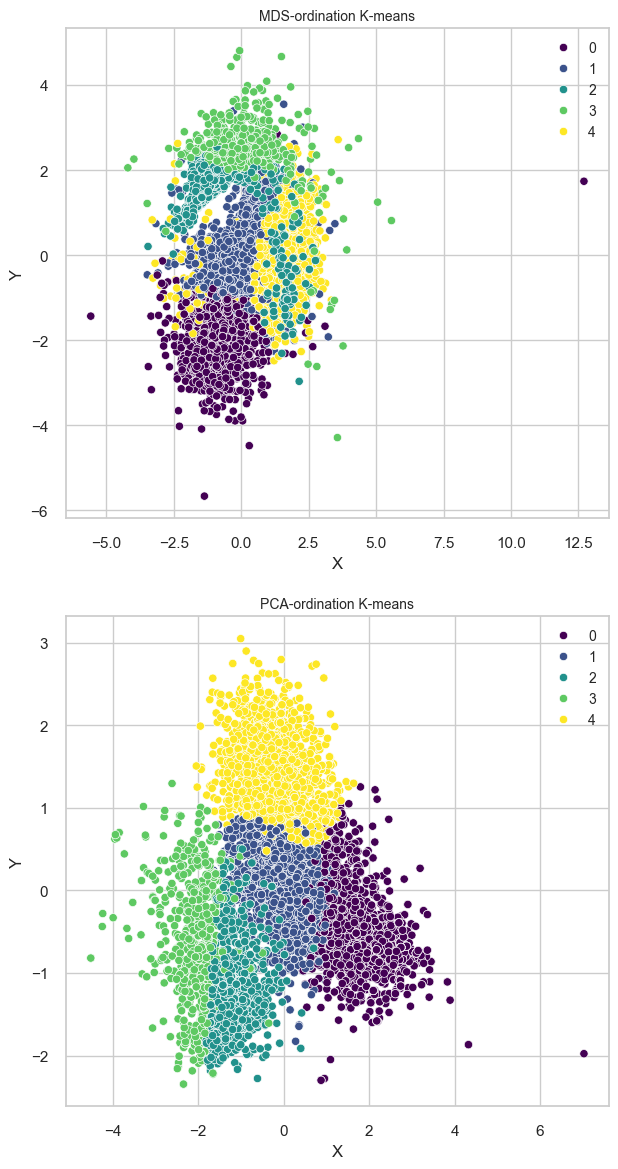

In [20]:
# построю ординации
ordination_mds['class_km'] = km_labels_vessels
ordination_pca['class_km'] = km_labels_vessels

plt.figure(figsize=(7, 14))   
sns.set(context = 'notebook', style = 'whitegrid', font_scale=1)

plt.subplot(2, 1, 1)
sns.scatterplot(data = ordination_mds, x='X', y='Y', hue='class_km', legend = 'full', palette='viridis')
plt.title('MDS-ordination K-means', fontsize=10)
plt.legend(bbox_to_anchor = (1,1), fontsize=10)
    
plt.subplot(2, 1, 2)
sns.scatterplot(data = ordination_pca, x='X', y='Y', hue='class_km', legend = 'full', palette='viridis')
plt.title('PCA-ordination K-means', fontsize=10)
plt.legend(bbox_to_anchor = (1,1), fontsize=10)
  
plt.subplots_adjust(wspace = 0.25)  

In [21]:
X['pca_x'] = ordination_pca['X']
X['pca_y'] = ordination_pca['Y']
X['mds_x'] = ordination_mds['X']
X['mds_y'] = ordination_mds['X']
X['k_labels'] = ordination_pca['class_km']
X

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,pca_x,pca_y,mds_x,mds_y,k_labels
0,0,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,3.416895,-1.106117,0.055004,0.055004,0
1,0,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,-0.159122,-0.305797,-0.660318,-0.660318,1
2,0,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,0.457854,-0.090312,-0.264848,-0.264848,1
3,0,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,0.941427,-0.170173,-0.372665,-0.372665,0
4,0,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,0.941427,-0.170173,-0.372554,-0.372554,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,1,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,-2.045566,-1.167876,-0.679187,-0.679187,3
6493,1,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,-2.451559,-0.847180,-0.430106,-0.430106,3
6494,1,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,-2.063401,-0.805970,-0.338459,-0.338459,3
6495,1,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,-2.333688,-1.571772,-0.900312,-0.900312,3


## Pipelines / sklearn features

In [22]:
pipeline_poly = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('pwr', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())  
])

# KBinsDiscretizer
binned_transformer = Pipeline(steps=[
    ('kbins', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform', subsample=None)),
    ('scaler', StandardScaler())  
])

# PowerTransformer
power_transformer = Pipeline(steps=[
    ('pwr', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())  
])

In [23]:
just_scale_cols = ['fixed acidity', 'volatile acidity', 'citric acid',
       'residual sugar', 'chlorides', 'free sulfur dioxide',
       'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol',
       'pca_x', 'pca_y', 'mds_x', 'mds_y']
selected_cols = ['residual sugar', 'pH', 'alcohol','mds_x', 'mds_y', 'density']

In [24]:
common_preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(drop='first'), ['k_labels']),
    ('num_tr_poly', pipeline_poly, selected_cols),
    ('num_tr_kb', binned_transformer, selected_cols),
    ('num_tr_pw', power_transformer, selected_cols), # var 2
    ('just', StandardScaler(), just_scale_cols)
], remainder='passthrough'
)

common_pipeline = Pipeline([
    ("preprocess", common_preprocessor)
])

In [25]:
print(X.shape)
print(y.shape)

(6497, 17)
(6497,)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(5197, 17)
(5197,)
(1300, 17)
(1300,)


In [27]:
X_train_proc = pd.DataFrame(data=common_pipeline.fit_transform(X_train), columns=common_pipeline.get_feature_names_out())
print(X_train_proc.shape)
print(X_train_proc.columns)

(5197, 59)
Index(['ohe__k_labels_1', 'ohe__k_labels_2', 'ohe__k_labels_3',
       'ohe__k_labels_4', 'num_tr_poly__residual sugar', 'num_tr_poly__pH',
       'num_tr_poly__alcohol', 'num_tr_poly__mds_x', 'num_tr_poly__mds_y',
       'num_tr_poly__density', 'num_tr_poly__residual sugar^2',
       'num_tr_poly__residual sugar pH', 'num_tr_poly__residual sugar alcohol',
       'num_tr_poly__residual sugar mds_x',
       'num_tr_poly__residual sugar mds_y',
       'num_tr_poly__residual sugar density', 'num_tr_poly__pH^2',
       'num_tr_poly__pH alcohol', 'num_tr_poly__pH mds_x',
       'num_tr_poly__pH mds_y', 'num_tr_poly__pH density',
       'num_tr_poly__alcohol^2', 'num_tr_poly__alcohol mds_x',
       'num_tr_poly__alcohol mds_y', 'num_tr_poly__alcohol density',
       'num_tr_poly__mds_x^2', 'num_tr_poly__mds_x mds_y',
       'num_tr_poly__mds_x density', 'num_tr_poly__mds_y^2',
       'num_tr_poly__mds_y density', 'num_tr_poly__density^2',
       'num_tr_kb__residual sugar', 'num_t

## Feature selection

In [28]:
common_pipeline_ws = Pipeline([
    ("preprocess", common_preprocessor),
    ('selection', SelectKBest(f_classif, k=42))
])

In [29]:
common_pipeline_ws.fit_transform(X_train, y_train)
print(common_pipeline_ws.get_feature_names_out())
X_train_selected = pd.DataFrame(common_pipeline_ws.fit_transform(X_train, y_train), columns=common_pipeline_ws.get_feature_names_out())
X_train_selected

['ohe__k_labels_1' 'ohe__k_labels_2' 'ohe__k_labels_4'
 'num_tr_poly__alcohol' 'num_tr_poly__mds_x' 'num_tr_poly__mds_y'
 'num_tr_poly__density' 'num_tr_poly__residual sugar mds_x'
 'num_tr_poly__residual sugar mds_y' 'num_tr_poly__pH alcohol'
 'num_tr_poly__pH mds_x' 'num_tr_poly__pH mds_y' 'num_tr_poly__alcohol^2'
 'num_tr_poly__alcohol mds_x' 'num_tr_poly__alcohol mds_y'
 'num_tr_poly__alcohol density' 'num_tr_poly__mds_x^2'
 'num_tr_poly__mds_x mds_y' 'num_tr_poly__mds_x density'
 'num_tr_poly__mds_y^2' 'num_tr_poly__mds_y density'
 'num_tr_poly__density^2' 'num_tr_kb__alcohol' 'num_tr_kb__mds_x'
 'num_tr_kb__mds_y' 'num_tr_kb__density' 'num_tr_pw__alcohol'
 'num_tr_pw__mds_x' 'num_tr_pw__mds_y' 'num_tr_pw__density'
 'just__volatile acidity' 'just__citric acid' 'just__residual sugar'
 'just__chlorides' 'just__total sulfur dioxide' 'just__density'
 'just__alcohol' 'just__pca_x' 'just__pca_y' 'just__mds_x' 'just__mds_y'
 'remainder__type']


,ohe__k_labels_1,ohe__k_labels_2,ohe__k_labels_4,num_tr_poly__alcohol,num_tr_poly__mds_x,num_tr_poly__mds_y,num_tr_poly__density,num_tr_poly__residual sugar mds_x,num_tr_poly__residual sugar mds_y,num_tr_poly__pH alcohol,...,just__residual sugar,just__chlorides,just__total sulfur dioxide,just__density,just__alcohol,just__pca_x,just__pca_y,just__mds_x,just__mds_y,remainder__type
0,1.0,0.0,0.0,0.782253,0.659082,0.659082,-1.041699,0.402148,0.402148,0.872349,...,-0.554885,-0.864470,-0.159381,-1.033763,0.672498,-0.439040,0.752702,0.604471,0.604471,0.0
1,0.0,0.0,1.0,1.564619,1.467630,1.467630,-1.167252,1.072779,1.072779,1.363207,...,0.243268,-0.864470,0.387687,-1.143480,1.759338,-0.058551,1.611126,1.551707,1.551707,0.0
2,0.0,0.0,1.0,0.782253,1.012723,1.012723,-1.185188,0.481526,0.481526,0.207013,...,-0.596893,-0.615266,0.564160,-1.160104,0.672498,0.213350,1.232088,1.006647,1.006647,0.0
3,1.0,0.0,0.0,0.408990,0.425299,0.425299,-0.808528,0.306413,0.306413,0.444746,...,-0.764926,-0.282994,-0.035850,-0.811004,0.254482,-0.325013,0.553547,0.350524,0.350524,0.0
4,0.0,0.0,0.0,-1.854255,-2.642701,-2.642701,1.881905,-6.178122,-6.178122,-2.104867,...,2.910781,0.021589,2.311248,1.945221,-1.501182,2.489744,-1.063959,-2.280085,-2.280085,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5192,0.0,1.0,0.0,-0.607787,-1.020399,-1.020399,0.572561,0.038629,0.038629,-0.205862,...,-0.743922,1.599880,-1.871175,0.552147,-0.665152,-1.140471,-1.446642,-0.995576,-0.995576,1.0
5193,1.0,0.0,0.0,0.245755,0.326193,0.326193,-0.629165,0.281651,0.281651,0.278281,...,-0.827938,-0.587576,0.070034,-0.631467,0.087276,-0.284158,0.459411,0.246065,0.246065,0.0
5194,0.0,0.0,0.0,0.487487,0.436421,0.436421,-0.144888,0.561656,0.561656,0.027772,...,0.936401,-0.532198,0.140624,-0.185950,0.338085,0.912432,0.596213,0.362370,0.362370,0.0
5195,1.0,0.0,0.0,-0.299498,0.037289,0.037289,-0.252505,0.218361,0.218361,-0.644454,...,0.054232,-0.227615,0.546513,-0.292342,-0.414342,0.689698,0.205258,-0.046224,-0.046224,0.0


# Resampling for fix class disbalance

In [30]:
# resampling for balance

sampler = RandomOverSampler(random_state=SEED)

X_train_oversampled, y_train_oversampled = sampler.fit_resample(X_train_selected, y_train)

print(X_train_oversampled.shape)
print(y_train_oversampled.shape)
y_train_oversampled.value_counts()

(11345, 42)
(11345,)


quality
7    2269
6    2269
5    2269
4    2269
8    2269
Name: count, dtype: int64

# Model selection

## Hyperparams tuinig for each type of model

0.3482075130770506
0.3769230769230769
0.7380030598423751


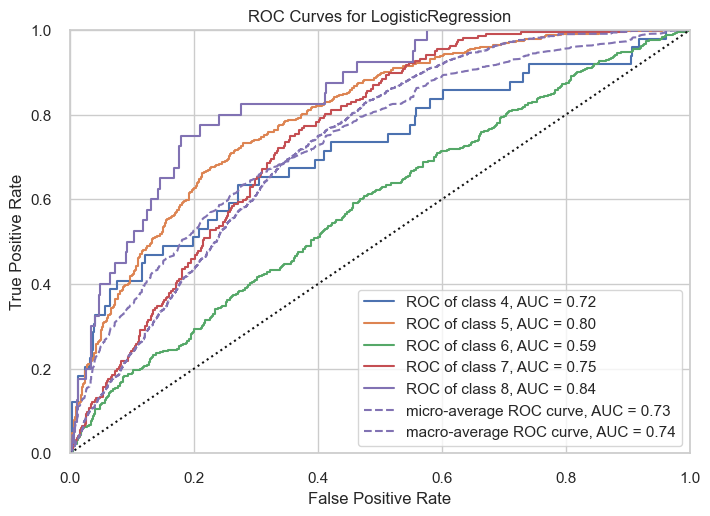

ROCAUC(ax=<Axes: title={'center': 'ROC Curves for LogisticRegression'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>,
       estimator=LogisticRegression(C=0.1, class_weight='balanced',
                                    multi_class='multinomial', penalty='l1',
                                    random_state=123, solver='saga'))


In [31]:
clf = LogisticRegression(random_state=SEED, class_weight='balanced', penalty='l1', C=0.1, solver='saga', multi_class='multinomial')
clf.fit(X_train_selected, y_train)
prediction = clf.predict(common_pipeline_ws.transform(X_test))
print(f1_score(prediction, y_test, average='weighted'))
print(accuracy_score(prediction, y_test))
preds = clf.predict_proba(common_pipeline_ws.transform(X_test))
print(roc_auc_score(y_test, preds, multi_class='ovr'))
print(roc_auc(clf, common_pipeline_ws.transform(X_test), y_test))

In [32]:
clf = LogisticRegression(random_state=SEED, class_weight='balanced', penalty='l2', C=10, solver='saga', multi_class='multinomial')
clf.fit(X_train_selected, y_train)
prediction = clf.predict(common_pipeline_ws.transform(X_test))
print(f1_score(prediction, y_test, average='weighted'))
print(accuracy_score(prediction, y_test))
preds = clf.predict_proba(common_pipeline_ws.transform(X_test))
print(roc_auc_score(y_test, preds, multi_class='ovr'))

0.3621918616447402
0.3892307692307692
0.7404305066081347


In [33]:
clf = LogisticRegression(random_state=SEED, class_weight='balanced', penalty=None, solver='saga', multi_class='ovr')
clf.fit(X_train_selected, y_train)
prediction = clf.predict(common_pipeline_ws.transform(X_test))
print(f1_score(prediction, y_test, average='weighted'))
print(accuracy_score(prediction, y_test))
preds = clf.predict_proba(common_pipeline_ws.transform(X_test))
print(roc_auc_score(y_test, preds, multi_class='ovr'))

0.4329043329592938
0.4430769230769231
0.7441384377744475


In [34]:
clf = LogisticRegression(random_state=SEED, class_weight='balanced', penalty='elasticnet', multi_class='multinomial',solver='saga',max_iter=300)
parametrs = {'l1_ratio':[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
             'C' : [0.001, 0.01,0.5, 0.1, 0.5,1,2,5,10,100]}

      #      'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']}
           # 'solver': ['sag', 'saga']}
           
random_cv = RandomizedSearchCV(estimator=clf,
    param_distributions=parametrs,
    cv=3, n_iter=50, 
    scoring = 'roc_auc_ovr_weighted',
    n_jobs = -1, verbose = 0, 
    return_train_score = True,
    random_state=SEED)

random_cv.fit(X_train_oversampled, y_train_oversampled)

best_ridge = random_cv.best_estimator_
print(best_ridge)

best_ridge_score = random_cv.best_score_
print(best_ridge_score)

LogisticRegression(C=100, class_weight='balanced', l1_ratio=0.2, max_iter=300,
                   multi_class='multinomial', penalty='elasticnet',
                   random_state=123, solver='saga')
0.7724382415379066


0.37015853898963
0.39
0.7452341242944026


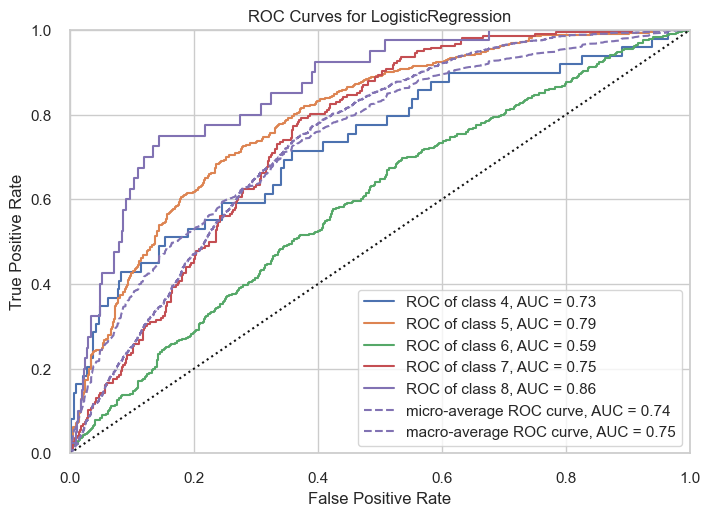

ROCAUC(ax=<Axes: title={'center': 'ROC Curves for LogisticRegression'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>,
       estimator=LogisticRegression(C=100, class_weight='balanced',
                                    l1_ratio=0.2, max_iter=300,
                                    multi_class='multinomial',
                                    penalty='elasticnet', random_state=123,
                                    solver='saga'))


In [35]:
prediction = best_ridge.predict(common_pipeline_ws.transform(X_test))
print(f1_score(prediction, y_test, average='weighted'))
print(accuracy_score(prediction, y_test))
preds = best_ridge.predict_proba(common_pipeline_ws.transform(X_test))
print(roc_auc_score(y_test, preds, multi_class='ovr'))
print(roc_auc(best_ridge, common_pipeline_ws.transform(X_test), y_test))

### SVM

In [36]:
from sklearn.svm import SVC

clf = SVC(random_state=SEED, max_iter=-1)
parametrs = {'kernel':['linear','poly','rbf','sigmoid'],
             'C' : [0.001, 0.01,0.5, 0.1, 0.5,1,2,5,10,100],
             'degree': range(1,20)}
           
random_cv = RandomizedSearchCV(estimator=clf,
    param_distributions=parametrs,
    cv=3, n_iter=50, 
    scoring = 'roc_auc_ovr_weighted',
    n_jobs = -1, verbose = 0, 
    return_train_score = True,
    random_state=SEED)

random_cv.fit(X_train_oversampled, y_train_oversampled)

best_svm = random_cv.best_estimator_
print(best_svm)

best_svm_score = random_cv.best_score_
print(best_svm_score)

KeyboardInterrupt: 

In [43]:
from sklearn.svm import SVC

clf = SVC(random_state=SEED, max_iter=-1)
parametrs = {'kernel':['sigmoid'],
             'C' : [0.001, 0.01,0.5, 0.1, 0.5,1,10,100],
             'degree': range(1,10)}
           
random_cv = RandomizedSearchCV(estimator=clf,
    param_distributions=parametrs,
    cv=2, n_iter=20, 
    scoring = 'roc_auc_ovr_weighted',
    n_jobs = -1, verbose = 2, 
    return_train_score = True,
    random_state=SEED)

random_cv.fit(X_train_oversampled, y_train_oversampled)

best_svm = random_cv.best_estimator_
print(best_svm)

best_svm_score = random_cv.best_score_
print(best_svm_score)

Fitting 2 folds for each of 20 candidates, totalling 40 fits
[CV] END ....................C=100, degree=1, kernel=sigmoid; total time=   0.8s
[CV] END ....................C=100, degree=9, kernel=sigmoid; total time=   0.8s
[CV] END ....................C=100, degree=1, kernel=sigmoid; total time=   0.8s
[CV] END ....................C=100, degree=9, kernel=sigmoid; total time=   0.8s
[CV] END ....................C=100, degree=3, kernel=sigmoid; total time=   0.8s
[CV] END ....................C=100, degree=3, kernel=sigmoid; total time=   0.8s
[CV] END ....................C=0.5, degree=9, kernel=sigmoid; total time=   0.9s
[CV] END ....................C=0.5, degree=9, kernel=sigmoid; total time=   1.0s
[CV] END ....................C=100, degree=2, kernel=sigmoid; total time=   0.7s
[CV] END ....................C=0.5, degree=6, kernel=sigmoid; total time=   0.9s
[CV] END ....................C=0.5, degree=6, kernel=sigmoid; total time=   0.9s
[CV] END ......................C=1, degree=8, ke

In [45]:
from sklearn.ensemble import RandomForestClassifier  

clf = RandomForestClassifier(random_state=SEED)
parametrs = { 'max_depth': range (1, 50, 2),
            'n_estimators': range (1, 50, 2),
            'min_samples_split':range(1, 50, 2),
            'min_samples_leaf':range(1, 50, 2)}

random_cv = RandomizedSearchCV(estimator=clf,
    param_distributions=parametrs,
    cv=2, n_iter=20, 
    scoring = 'roc_auc_ovr_weighted',
    n_jobs = -1, verbose = 2, 
    return_train_score = True,
    random_state=SEED)

random_cv.fit(X_train_oversampled, y_train_oversampled)

best_forest = random_cv.best_estimator_
best_forest

best_forest_score = random_cv.best_score_
best_forest_score

Fitting 2 folds for each of 20 candidates, totalling 40 fits
[CV] END max_depth=3, min_samples_leaf=39, min_samples_split=43, n_estimators=11; total time=   0.1s
[CV] END max_depth=3, min_samples_leaf=7, min_samples_split=19, n_estimators=11; total time=   0.1s
[CV] END max_depth=3, min_samples_leaf=39, min_samples_split=43, n_estimators=11; total time=   0.1s
[CV] END max_depth=3, min_samples_leaf=7, min_samples_split=19, n_estimators=11; total time=   0.1s
[CV] END max_depth=25, min_samples_leaf=15, min_samples_split=49, n_estimators=3; total time=   0.0s
[CV] END max_depth=25, min_samples_leaf=15, min_samples_split=49, n_estimators=3; total time=   0.1s
[CV] END max_depth=49, min_samples_leaf=23, min_samples_split=15, n_estimators=1; total time=   0.0s
[CV] END max_depth=49, min_samples_leaf=23, min_samples_split=15, n_estimators=1; total time=   0.0s
[CV] END max_depth=25, min_samples_leaf=21, min_samples_split=43, n_estimators=7; total time=   0.1s
[CV] END max_depth=25, min_sampl

np.float64(0.9302840348976814)

0.5575736291353317
0.5584615384615385
0.793592443074034


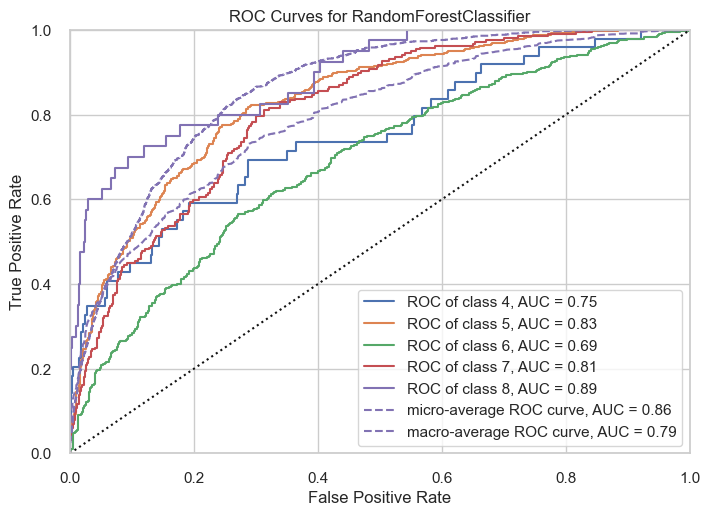

ROCAUC(ax=<Axes: title={'center': 'ROC Curves for RandomForestClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>,
       estimator=RandomForestClassifier(max_depth=29, min_samples_leaf=5,
                                        min_samples_split=29, n_estimators=49,
                                        random_state=123))


In [46]:
prediction = best_forest.predict(common_pipeline_ws.transform(X_test))
print(f1_score(prediction, y_test, average='weighted'))
print(accuracy_score(prediction, y_test))
preds = best_forest.predict_proba(common_pipeline_ws.transform(X_test))
print(roc_auc_score(y_test, preds, multi_class='ovr'))
print(roc_auc(best_forest, common_pipeline_ws.transform(X_test), y_test))

In [47]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=SEED)
parametrs = { 'max_depth': range (1, 50, 2),
            'min_samples_split':range(1, 50, 2),
            'min_samples_leaf':range(1, 50, 2)}

random_cv = RandomizedSearchCV(estimator=clf,
    param_distributions=parametrs,
    cv=2, n_iter=20, 
    scoring = 'roc_auc_ovr_weighted',
    n_jobs = -1, verbose = 2, 
    return_train_score = True,
    random_state=SEED)

random_cv.fit(X_train_oversampled, y_train_oversampled)

best_tree = random_cv.best_estimator_
best_tree

best_tree_score = random_cv.best_score_
best_tree_score

Fitting 2 folds for each of 20 candidates, totalling 40 fits
[CV] END max_depth=11, min_samples_leaf=37, min_samples_split=15; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=7, min_samples_split=43; total time=   0.1s
[CV] END max_depth=11, min_samples_leaf=37, min_samples_split=15; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=7, min_samples_split=43; total time=   0.1s
[CV] END max_depth=37, min_samples_leaf=31, min_samples_split=43; total time=   0.2s
[CV] END max_depth=37, min_samples_leaf=31, min_samples_split=43; total time=   0.2s
[CV] END max_depth=39, min_samples_leaf=31, min_samples_split=5; total time=   0.1s
[CV] END max_depth=39, min_samples_leaf=31, min_samples_split=5; total time=   0.2s
[CV] END max_depth=17, min_samples_leaf=17, min_samples_split=37; total time=   0.2s
[CV] END max_depth=45, min_samples_leaf=25, min_samples_split=9; total time=   0.1s
[CV] END max_depth=17, min_samples_leaf=17, min_samples_split=37; total time=   0.1s
[CV] END ma

np.float64(0.9062148036989162)

In [50]:
from lightgbm import LGBMClassifier  

In [51]:
# RandomizedSearch для LightGBM

# параметры
num_leaves = [10, 50, 100, 200, 300, 400, 500, 700, 1000]
min_child_samples = [10, 20, 50, 100, 200, 400, 1000]
n_estimators = [10, 50, 100, 200, 300, 400, 500, 700, 1000]
learning_rate = [1.0, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]

hyperparameter_grid = {'n_estimators': n_estimators,
    'num_leaves': num_leaves,
    'min_child_samples': min_child_samples,
    'learning_rate': learning_rate}

model_lgbm = LGBMClassifier(random_state=SEED) 

random_cv = RandomizedSearchCV(estimator=model_lgbm,
    param_distributions=hyperparameter_grid,
    cv=3, n_iter=20, 
    scoring = 'roc_auc_ovr_weighted',
    n_jobs = -1, verbose = 2, 
    return_train_score = True,
    random_state=SEED)

random_cv.fit(X_train_oversampled, y_train_oversampled)

lgbm_best_model = random_cv.best_estimator_
lgbm_best_model
lgbm_best_score = random_cv.best_score_
lgbm_best_score

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005295 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005420 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7473
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005651 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7466
[LightGBM] [Info] Number of data points in the train set: 7563, number of used features: 42
[LightGBM] [Info] Total Bins 7495
[LightGBM] [Info] N

Exception ignored on calling ctypes callback function: <function _log_callback at 0x1224e00e0>
Traceback (most recent call last):
  File "/Users/vladkozlovskiy/Desktop/GIT/classification_task/ml_env/lib/python3.11/site-packages/lightgbm/basic.py", line 287, in _log_callback
    def _log_callback(msg: bytes) -> None:
    
KeyboardInterrupt: 


KeyboardInterrupt: 

In [ ]:
#clf_xgb = xgb.XGBClassifier()
# выбор параметров тот же что для LightGBM

#random_cv = RandomizedSearchCV(estimator=clf_xgb,
#    param_distributions=hyperparameter_grid,
#    cv=5, n_iter=50, 
#    scoring = 'balanced_accuracy',
#    n_jobs = -1, verbose = 2, 
#    return_train_score = True,
#    random_state=22345)

#random_cv.fit(features_train, target_train)

#best_xgb = random_cv.best_estimator_
#best_xgb

#best_xgb_score = random_cv.best_score_
#best_xgb_score

In [ ]:
model_dummy = DummyClassifier(strategy="most_frequent")
model_dummy.fit(features_train, target_train)
model_dummy.predict(features_train)
model_dummy.score(features_train, target_train)